# Supernova Lightcurve: One-Zone Arnett Model

Starting from energy conservation in an expanding radiation-dominated sphere:

$$\frac{dE}{dt} = -\frac{E}{t+t_0} - \frac{E(t+t_0)}{t_m^2} + \dot{Q}(t)
\qquad \text{with} \qquad
t_0 = \frac{R_0}{v}, \quad t_m = \sqrt{\frac{3\kappa M}{4\pi v c}}$$

The integrating factor $(t+t_0)\exp[(t+t_0)^2/2t_m^2]$ turns this into a perfect
derivative that integrates exactly to:

$$\boxed{L(t) = \frac{e^{-(t+t_0)^2/2t_m^2}}{t_m^2}
\Bigl[\,t_0\,E_0\,e^{t_0^2/2t_m^2}
+ \int_0^t (t'+t_0)\,e^{(t'+t_0)^2/2t_m^2}\,\dot{Q}(t')\,dt'\,\Bigr]}$$


In [ ]:
import numpy as np
from scipy.integrate import solve_ivp, cumulative_trapezoid
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'font.family':      'serif',
    'font.serif':       ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    13,
    'legend.fontsize':   10,
    'figure.dpi':        120,
    'axes.grid':         True,
    'grid.alpha':        0.25,
})

# Project colour palette
COL_L       = '#1E90FF'  # dodgerblue  -- L(t) integral
COL_ODE     = '#FF4500'  # orangered   -- L(t) ODE check
COL_Q       = '#6B8E23'  # olivedrab   -- Q-dot heating
COL_APPROX  = '#800000'  # maroon      -- timescale-crossing estimate
COL_PEAK    = '#000080'  # navy        -- true L=Q peak
COL_ENERGY  = '#6B8E23'  # olivedrab   -- internal energy E(t)

### 1. Physical Constants and Decay Parameters

All quantities in CGS. Radioactive decay constants from Nadyozhin (1994).


In [2]:
# ── Physical constants ────────────────────────────────────────────────────────
c_light = 3.0e10       # speed of light     [cm/s]
M_sun   = 1.989e33     # solar mass         [g]
R_sun   = 6.957e10     # solar radius       [cm]
L_sun   = 3.828e33     # solar luminosity   [erg/s]
day     = 86400.0      # seconds per day

# ── Ni-56 -> Co-56 -> Fe-56 decay chain (Nadyozhin 1994) ────────────────────
tau_Ni  = 8.8   * day  # Ni-56 e-folding time   [s]
tau_Co  = 111.3 * day  # Co-56 e-folding time   [s]
eps_Ni  = 3.90e10      # Ni-56 specific power   [erg/s/g]
eps_Co  = 6.78e9       # Co-56 specific power   [erg/s/g]


### 2. Model Parameters

Fiducial SN II values (red supergiant progenitor). Adjust these cells to explore
different progenitor or explosion configurations.


In [3]:
# ── Ejecta ────────────────────────────────────────────────────────────────────
kappa  = 0.10           # electron-scattering opacity    [cm^2/g]
M_ej   = 10.0 * M_sun  # total ejecta mass              [g]
v_ej   = 5000e5         # characteristic velocity        [cm/s]  (5000 km/s)
R_0    = 500.0 * R_sun  # progenitor radius (RSG)        [cm]

# ── Energy inputs ─────────────────────────────────────────────────────────────
M_Ni   = 0.05 * M_sun  # synthesised nickel mass        [g]
E_0    = 1e49           # shock-deposited thermal energy [erg]

# ── Time grid ─────────────────────────────────────────────────────────────────
# We start from a very small time so that both methods share the same t=0
# initial condition (avoiding any singularity -- t0 > 0 keeps 1/(t+t0) finite)
t_start_days = 1e-3    # essentially zero
t_max_days   = 300
N_pts        = 1200

t_days = np.linspace(t_start_days, t_max_days, N_pts)
t_arr  = t_days * day


### 3. Derived Timescales

$$t_0 = \frac{R_0}{v}, \qquad
t_m = \sqrt{\frac{3\kappa M_\mathrm{ej}}{4\pi\,v\,c}}$$

The analytic estimate $t_\mathrm{SN} \approx t_m - t_0$ comes from the **timescale
crossing** condition $t_\mathrm{diff}(t) = t_\mathrm{exp}(t)$.  This is a useful
order-of-magnitude argument, but it is **not** the true peak condition.

The true peak condition is derived from $dL/dt = 0$, which (as shown in Section 7)
gives **Arnett's rule**: $L(t_\mathrm{peak}) = \dot{Q}(t_\mathrm{peak})$.  The true
peak is where the luminosity curve and the heating curve intersect.  When
$\tau_\mathrm{decay}$ is comparable to $t_m$, the two estimates can differ significantly.


In [4]:
t_0  = R_0 / v_ej
t_m  = np.sqrt(3.0 * kappa * M_ej / (4.0 * np.pi * v_ej * c_light))
t_SN_approx = t_m - t_0   # timescale-crossing estimate (approximate only)

print(f"t_0       = {t_0          / day:7.3f} days   (R_0 / v)")
print(f"t_m       = {t_m          / day:7.3f} days   (Arnett timescale)")
print(f"t_SN_approx = {t_SN_approx / day:5.1f} days   (t_diff=t_exp crossing -- approximate)")
print(f"  Note: the TRUE peak requires solving L(t) = Q(t) numerically (see Section 7).")

t_exp_arr  = t_arr + t_0
t_diff_arr = t_m**2 / (t_arr + t_0)


t_0       =   0.805 days   (R_0 / v)
t_m       =  65.120 days   (Arnett timescale)
t_SN_approx =  64.3 days   (t_diff=t_exp crossing -- approximate)
  Note: the TRUE peak requires solving L(t) = Q(t) numerically (see Section 7).


### 4. Radioactive Heating Function

$$\dot{Q}(t) = M_\mathrm{Ni}
\bigl[\epsilon_\mathrm{Ni}\,e^{-t/\tau_\mathrm{Ni}}
+ \epsilon_\mathrm{Co}(e^{-t/\tau_\mathrm{Co}} - e^{-t/\tau_\mathrm{Ni}})\bigr]$$

At $t \ll \tau_\mathrm{Ni} = 8.8$ d the Ni-56 term dominates;
at $t \gg \tau_\mathrm{Ni}$ the longer-lived Co-56 tail takes over.


In [5]:
def Q_dot(t, Mni=None):
    """
    Total radioactive power from the Ni-56 -> Co-56 -> Fe-56 chain.

    Parameters
    ----------
    t   : float or ndarray   Time [s]
    Mni : float              Nickel mass [g]; defaults to global M_Ni
    Returns
    -------
    Power [erg/s]
    """
    if Mni is None:
        Mni = M_Ni
    Ni_term = eps_Ni * np.exp(-t / tau_Ni)
    Co_term = eps_Co * (np.exp(-t / tau_Co) - np.exp(-t / tau_Ni))
    return Mni * (Ni_term + Co_term)

Q_arr = Q_dot(t_arr)
print(f"Q_dot(t=0)    = {Q_dot(0)    / L_sun:.3e}  L_sun")
print(f"Q_dot(t_m)    = {Q_dot(t_m) / L_sun:.3e}  L_sun  (at timescale crossing)")


Q_dot(t=0)    = 1.013e+09  L_sun
Q_dot(t_m)    = 9.863e+07  L_sun  (at timescale crossing)


### 5. Method 1 -- Arnett Integral

We factor the decaying Gaussian envelope *outside* the integrand:

$$L(t) = \frac{1}{t_m^2}
\Bigl[t_0 E_0\,e^{(t_0^2-(t+t_0)^2)/2t_m^2}
+ \int_0^t (t'\!+t_0)\,e^{((t'\!+t_0)^2-(t+t_0)^2)/2t_m^2}\dot{Q}(t')\,dt'\Bigr]$$

Since $t' \le t$, the exponent $(t'+t_0)^2-(t+t_0)^2 \le 0$ everywhere, so the
integrand's exponential factor is always $\in[0,1]$ -- no overflow at any time.

The running integral $J(t) = \int_0^t \ldots\,dt'$ is computed once on the
full grid with `cumulative_trapezoid`, then multiplied by the common decaying
prefactor. Starting the grid at $t \approx 0$ means $J(t_\mathrm{start}) \approx 0$
and the boundary term $t_0 E_0 e^{\ldots}$ captures the $t=0$ initial condition.


In [6]:
def compute_L_integral(t_arr, t_0, t_m, E_0, Q_func):
    """
    Evaluate L(t) from the Arnett convolution integral.

    Numerically stable: all exponentials inside the integrand are <= 1.

    Parameters
    ----------
    t_arr  : ndarray    Time grid [s] (should start near 0)
    t_0    : float      R_0/v  [s]
    t_m    : float      Arnett timescale [s]
    E_0    : float      Initial internal energy [erg]  at t=0
    Q_func : callable   Heating rate [erg/s] as a function of t [s]

    Returns
    -------
    L_arr  : ndarray    Bolometric luminosity [erg/s]
    """
    # Arnett kernel f(t') = (t'+t0) * exp((t'+t0)^2 / 2tm^2)
    # grows with time, but is always cancelled by the decaying envelope
    kernel    = (t_arr + t_0) * np.exp((t_arr + t_0)**2 / (2.0 * t_m**2))

    # Cumulative running integral J(t) = integral_0^t f(t') Q(t') dt'
    # t_arr[0] ~ 0, so prepending 0 is correct for the initial value
    J = np.concatenate(([0.0], cumulative_trapezoid(kernel * Q_func(t_arr), t_arr)))

    # Boundary term: contribution of E_0 at t=0
    E0_term  = t_0 * E_0 * np.exp(t_0**2 / (2.0 * t_m**2))

    # Decaying Gaussian envelope (always <= 1 since t >= 0)
    envelope = np.exp(-(t_arr + t_0)**2 / (2.0 * t_m**2))

    return (E0_term + J) * envelope / t_m**2

L_integral = compute_L_integral(t_arr, t_0, t_m, E_0, Q_dot)

i_pk = np.argmax(L_integral)
print(f"Peak L (integral)  = {L_integral[i_pk]/L_sun:.4e}  L_sun")
print(f"Peak t (integral)  = {t_days[i_pk]:.1f}  days")


Peak L (integral)  = 7.1582e+07  L_sun
Peak t (integral)  = 100.3  days


### 6. Method 2 -- ODE Solver

Directly integrate the first-order linear energy ODE:

$$\frac{dE}{dt} = -\frac{E}{t+t_0} - \frac{E(t+t_0)}{t_m^2} + \dot{Q}(t),
\qquad E(t=0) = E_0$$

then recover $L(t) = E(t)\,(t+t_0)\,/\,t_m^2$.
Since $t_0 > 0$, the coefficient $1/(t+t_0)$ is perfectly well-behaved at $t=0$.


In [7]:
def compute_L_ode(t_arr, t_0, t_m, E_0, Q_func):
    """
    Solve the energy ODE and return L(t) and E(t).

    Parameters
    ----------
    t_arr  : ndarray    Evaluation times [s]
    t_0    : float      R_0/v  [s]
    t_m    : float      Arnett timescale [s]
    E_0    : float      E(t=0) initial energy [erg]
    Q_func : callable   Heating rate [erg/s]

    Returns
    -------
    L_arr, E_arr : ndarrays
    """
    def rhs(t, y):
        E = y[0]
        return [-E/(t + t_0) - E*(t + t_0)/t_m**2 + Q_func(t)]

    # Start integration from t=0 (t_0>0 keeps 1/(t+t0) regular at t=0)
    sol = solve_ivp(
        rhs,
        t_span = (0.0, t_arr[-1]),
        y0     = [E_0],
        t_eval = t_arr,
        method = 'RK45',
        rtol   = 1e-10,
        atol   = 1e-12,
    )
    if not sol.success:
        raise RuntimeError("ODE solver failed: " + sol.message)

    E_arr = sol.y[0]
    L_arr = E_arr * (t_arr + t_0) / t_m**2
    return L_arr, E_arr

L_ode, E_ode = compute_L_ode(t_arr, t_0, t_m, E_0, Q_dot)

i_pk = np.argmax(L_ode)
print(f"Peak L (ODE)  = {L_ode[i_pk]/L_sun:.4e}  L_sun")
print(f"Peak t (ODE)  = {t_days[i_pk]:.1f}  days")

rel_diff = np.abs(L_ode - L_integral) / (np.abs(L_integral) + 1.0)
print(f"\nMax relative difference between methods: {np.max(rel_diff):.2e}  (should be << 1)")


Peak L (ODE)  = 7.1582e+07  L_sun
Peak t (ODE)  = 100.3  days

Max relative difference between methods: 1.08e-04  (should be << 1)


### 7. Main Plots

The key diagnostic is the **top-right panel**: the true lightcurve peak is where
$L(t)$ crosses $\dot{Q}(t)$ from below.  This is Arnett's rule $L_\mathrm{peak} = \dot{Q}(t_\mathrm{peak})$,
derived exactly from $dL/dt = 0$.

The simpler estimate $t_m - t_0$ (timescale crossing, bottom-left panel) is only
accurate when $\tau_\mathrm{decay} \ll t_m$ or $\tau_\mathrm{decay} \gg t_m$.
Here $\tau_\mathrm{Co} = 111\,\mathrm{d} \sim t_m = 65\,\mathrm{d}$, so the Co-56
tail sustains $\dot{Q}$ well past $t_m$ and shifts the true peak to $\sim 100$ d.


Timescale-crossing estimate  t_m - t_0 = 64.3 days
True peak (L = Q crossing)  t_peak = 100.1 days
Peak luminosity  L_peak = 7.158e+07 L_sun
Q_dot at peak  Q(t_peak) = 7.168e+07 L_sun
Arnett ratio  L/Q = 0.9986 (should be ~1.0)


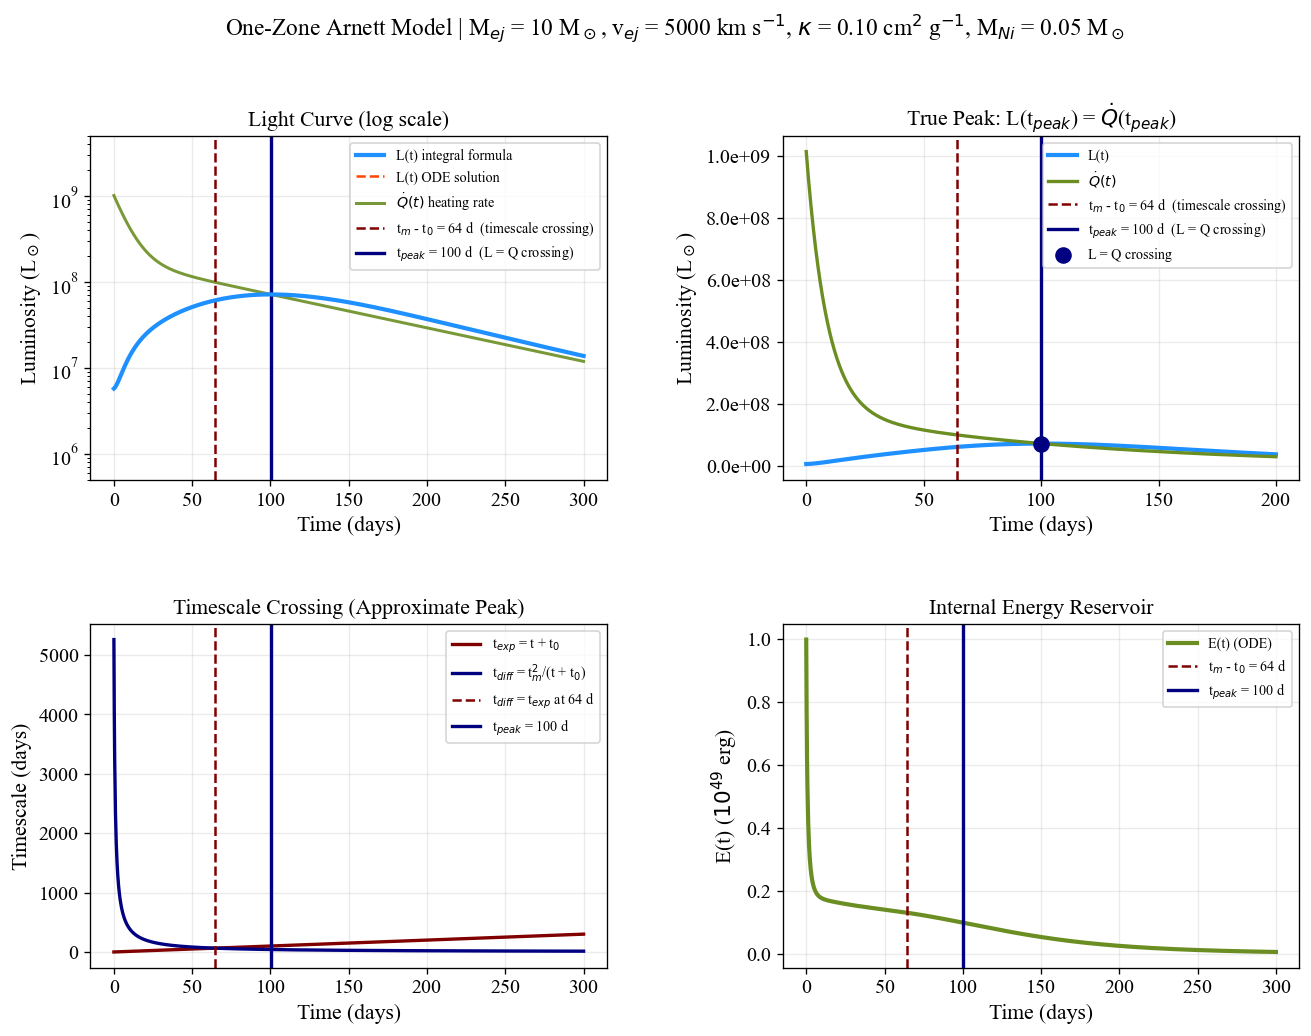

In [8]:
# ── Find the true peak: where L(t) crosses Q(t) from below ───────────────────
# The true peak condition is dL/dt = 0  =>  L(t_peak) = Q_dot(t_peak)

LminusQ = L_integral - Q_arr
sign_changes = np.where(np.diff(np.sign(LminusQ)))[0]

t_peak_true = t_days[sign_changes[0]]
L_peak_true = L_integral[sign_changes[0]]

print(f"Timescale-crossing estimate  t_m - t_0 = {(t_m - t_0)/day:.1f} days")
print(f"True peak (L = Q crossing)  t_peak = {t_peak_true:.1f} days")
print(f"Peak luminosity  L_peak = {L_peak_true/L_sun:.3e} L_sun")
print(f"Q_dot at peak  Q(t_peak) = {Q_dot(t_peak_true*day)/L_sun:.3e} L_sun")
print(f"Arnett ratio  L/Q = {L_peak_true / Q_dot(t_peak_true*day):.4f} (should be ~1.0)")

fig = plt.figure(figsize=(13, 9))
gs  = GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.34)

approx_lbl = (
    rf"t$_m$ - t$_0$ = {(t_m-t_0)/day:.0f} d"
    rf"  (timescale crossing)"
)

true_lbl = (
    rf"t$_{{peak}}$ = {t_peak_true:.0f} d"
    rf"  (L = Q crossing)"
)

# ── Top-left: log lightcurve showing both estimates ──────────────────────────
ax0 = fig.add_subplot(gs[0, 0])

ax0.plot(
    t_days, L_integral/L_sun,
    color=COL_L, lw=2.5,
    label='L(t) integral formula',
    zorder=3
)

ax0.plot(
    t_days, L_ode/L_sun,
    color=COL_ODE, lw=1.5, ls='--',
    label='L(t) ODE solution',
    zorder=2
)

ax0.plot(
    t_days, Q_arr/L_sun,
    color=COL_Q, lw=1.8,
    label=r'$\dot{Q}(t)$ heating rate',
    alpha=0.9
)

ax0.axvline(
    (t_m-t_0)/day,
    color=COL_APPROX,
    ls='--',
    lw=1.5,
    label=approx_lbl
)

ax0.axvline(
    t_peak_true,
    color=COL_PEAK,
    ls='-',
    lw=2.0,
    label=true_lbl
)

ax0.set_yscale('log')
ax0.set_ylim(5e5, 5e9)
ax0.set_xlabel('Time (days)')
ax0.set_ylabel(r'Luminosity (L$_\odot$)')
ax0.set_title('Light Curve (log scale)')
ax0.legend(fontsize=8.5)

# ── Top-right: L vs Q zoom showing the crossing ──────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])

mask = t_days < 200

ax1.plot(
    t_days[mask],
    L_integral[mask]/L_sun,
    color=COL_L,
    lw=2.5,
    label='L(t)'
)

ax1.plot(
    t_days[mask],
    Q_arr[mask]/L_sun,
    color=COL_Q,
    lw=2.0,
    label=r'$\dot{Q}(t)$'
)

ax1.axvline(
    (t_m-t_0)/day,
    color=COL_APPROX,
    ls='--',
    lw=1.5,
    label=approx_lbl
)

ax1.axvline(
    t_peak_true,
    color=COL_PEAK,
    ls='-',
    lw=2.0,
    label=true_lbl
)

ax1.scatter(
    [t_peak_true],
    [L_peak_true/L_sun],
    color=COL_PEAK,
    s=80,
    zorder=5,
    label='L = Q crossing'
)

ax1.set_xlabel('Time (days)')
ax1.set_ylabel(r'Luminosity (L$_\odot$)')
ax1.set_title(r'True Peak: L(t$_{peak}$) = $\dot{Q}$(t$_{peak}$)')
ax1.legend(fontsize=8.5)

ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.1e}')
)

# ── Bottom-left: timescale crossing ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])

ax2.plot(
    t_days,
    t_exp_arr/day,
    color=COL_APPROX,
    lw=2.0,
    label='t$_{exp}$ = t + t$_0$'
)

ax2.plot(
    t_days,
    t_diff_arr/day,
    color=COL_PEAK,
    lw=2.0,
    label='t$_{diff}$ = t$_m^2$/(t + t$_0$)'
)

ax2.axvline(
    (t_m-t_0)/day,
    color=COL_APPROX,
    ls='--',
    lw=1.5,
    label=rf't$_{{diff}}$ = t$_{{exp}}$ at {(t_m-t_0)/day:.0f} d'
)

ax2.axvline(
    t_peak_true,
    color=COL_PEAK,
    ls='-',
    lw=2.0,
    label=rf't$_{{peak}}$ = {t_peak_true:.0f} d'
)

ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Timescale (days)')
ax2.set_title('Timescale Crossing (Approximate Peak)')
ax2.legend(fontsize=8.5)

# ── Bottom-right: internal energy E(t) ───────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])

ax3.plot(
    t_days,
    E_ode/1e49,
    color=COL_ENERGY,
    lw=2.5,
    label='E(t) (ODE)'
)

ax3.axvline(
    (t_m-t_0)/day,
    color=COL_APPROX,
    ls='--',
    lw=1.5,
    label=rf't$_m$ - t$_0$ = {(t_m-t_0)/day:.0f} d'
)

ax3.axvline(
    t_peak_true,
    color=COL_PEAK,
    ls='-',
    lw=2.0,
    label=rf't$_{{peak}}$ = {t_peak_true:.0f} d'
)

ax3.set_xlabel('Time (days)')
ax3.set_ylabel(r'E(t) ($10^{49}$ erg)')
ax3.set_title('Internal Energy Reservoir')
ax3.legend(fontsize=8.5)

fig.suptitle(
    rf"One-Zone Arnett Model | "
    rf"M$_{{ej}}$ = {M_ej/M_sun:.0f} M$_\odot$, "
    rf"v$_{{ej}}$ = {v_ej/1e5:.0f} km s$^{{-1}}$, "
    rf"$\kappa$ = {kappa:.2f} cm$^2$ g$^{{-1}}$, "
    rf"M$_{{Ni}}$ = {M_Ni/M_sun:.2f} M$_\odot$",
    fontsize=14,
    y=0.995,
)

# plt.savefig('sn_lightcurve_main.png', dpi=300, bbox_inches='tight')
plt.show()

### 8. Parameter Study

| Parameter | Scaling | Effect |
|-----------|---------|--------|
| $M_\mathrm{Ni}$ | $L_\mathrm{peak} \propto M_\mathrm{Ni}$ | amplitude only |
| $M_\mathrm{ej}$ | $t_m \propto M_\mathrm{ej}^{1/2}$ | broader, later peak |
| $\kappa$ | $t_m \propto \kappa^{1/2}$ | broader, later peak |


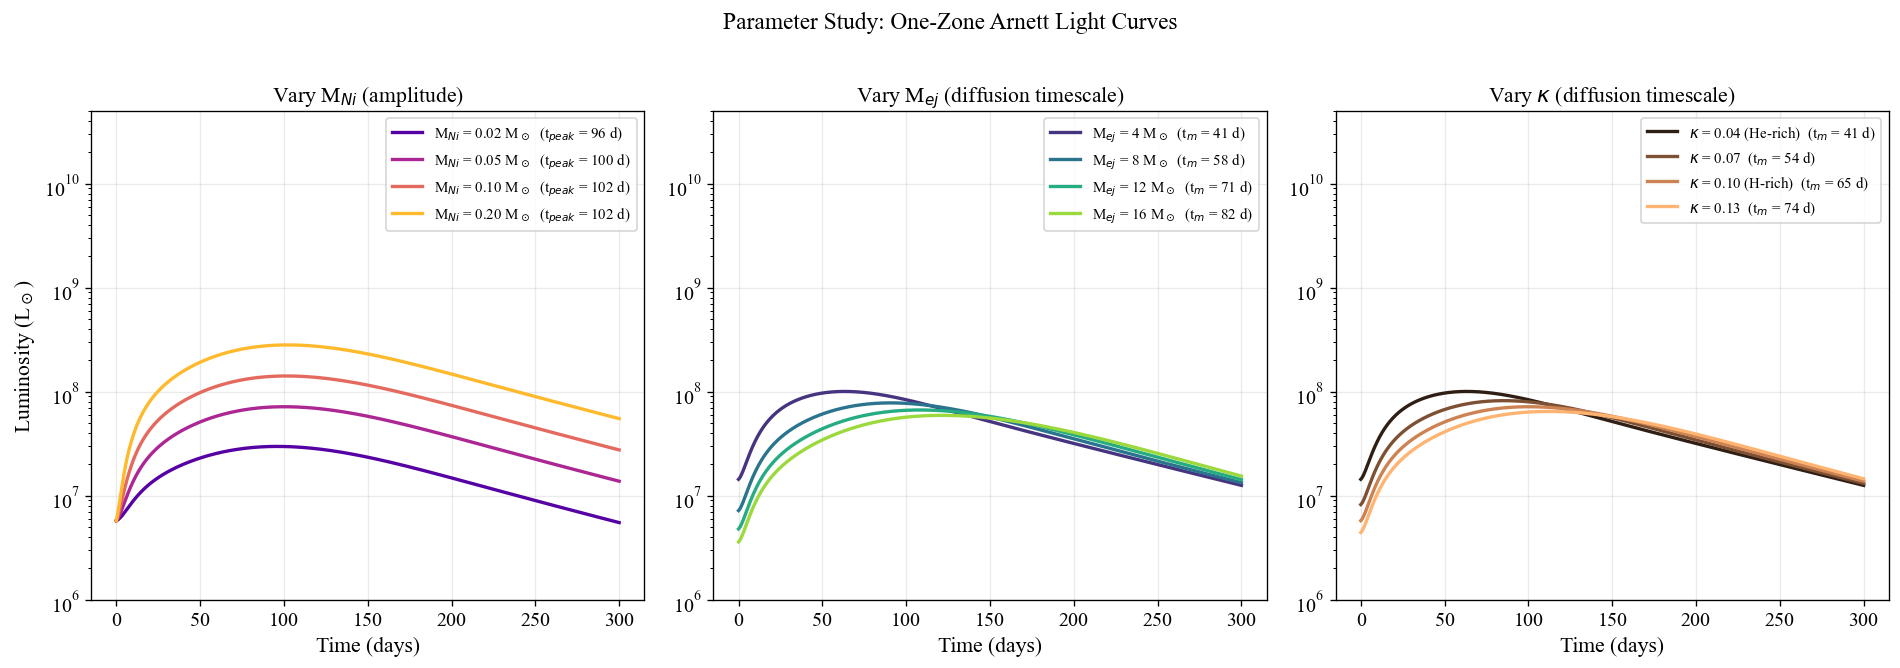

In [9]:
def run_model(M_ej_val, v_ej_val, kappa_val, M_Ni_val, E_0_val, R_0_val, t_arr):
    """Convenience wrapper: integral lightcurve for arbitrary parameters."""
    t0_ = R_0_val / v_ej_val
    tm_ = np.sqrt(3.0 * kappa_val * M_ej_val / (4.0 * np.pi * v_ej_val * c_light))
    Qdot_ = lambda t: Q_dot(t, Mni=M_Ni_val)
    L_  = compute_L_integral(t_arr, t0_, tm_, E_0_val, Qdot_)
    tp_ = t_arr[np.argmax(L_)] / day
    return L_, tp_, tm_ / day


fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=False)

# ── Vary M_Ni ────────────────────────────────────────────────────────────────
ax = axes[0]
for Mni, col in zip(
    [0.02, 0.05, 0.10, 0.20],
    plt.cm.plasma(np.linspace(0.15, 0.85, 4))
):
    L_, tp_, _ = run_model(M_ej, v_ej, kappa, Mni*M_sun, E_0, R_0, t_arr)

    ax.plot(
        t_days,
        L_/L_sun,
        color=col,
        lw=2.0,
        label=rf"M$_{{Ni}}$ = {Mni:.2f} M$_\odot$  (t$_{{peak}}$ = {tp_:.0f} d)"
    )

ax.set_yscale('log')
ax.set_ylim(1e6, 5e10)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'Luminosity (L$_\odot$)')
ax.set_title(r'Vary M$_{Ni}$ (amplitude)')
ax.legend(fontsize=9)

# ── Vary M_ej ────────────────────────────────────────────────────────────────
ax = axes[1]
for Mej, col in zip(
    [4, 8, 12, 16],
    plt.cm.viridis(np.linspace(0.15, 0.85, 4))
):
    L_, tp_, tm_ = run_model(Mej*M_sun, v_ej, kappa, M_Ni, E_0, R_0, t_arr)

    ax.plot(
        t_days,
        L_/L_sun,
        color=col,
        lw=2.0,
        label=rf"M$_{{ej}}$ = {Mej:.0f} M$_\odot$  (t$_m$ = {tm_:.0f} d)"
    )

ax.set_yscale('log')
ax.set_ylim(1e6, 5e10)
ax.set_xlabel('Time (days)')
ax.set_title(r'Vary M$_{ej}$ (diffusion timescale)')
ax.legend(fontsize=9)

# ── Vary kappa ───────────────────────────────────────────────────────────────
ax = axes[2]

kappa_list  = [0.04, 0.07, 0.10, 0.13]
kappa_names = ['0.04 (He-rich)', '0.07', '0.10 (H-rich)', '0.13']

for kap, klbl, col in zip(
    kappa_list,
    kappa_names,
    plt.cm.copper(np.linspace(0.15, 0.9, 4))
):
    L_, tp_, tm_ = run_model(M_ej, v_ej, kap, M_Ni, E_0, R_0, t_arr)

    ax.plot(
        t_days,
        L_/L_sun,
        color=col,
        lw=2.0,
        label=rf"$\kappa$ = {klbl}  (t$_m$ = {tm_:.0f} d)"
    )

ax.set_yscale('log')
ax.set_ylim(1e6, 5e10)
ax.set_xlabel('Time (days)')
ax.set_title(r'Vary $\kappa$ (diffusion timescale)')
ax.legend(fontsize=9)

plt.suptitle(
    'Parameter Study: One-Zone Arnett Light Curves',
    fontsize=14,
    y=1.01
)

plt.tight_layout()
# plt.savefig('sn_parameter_study.png', dpi=300, bbox_inches='tight')
plt.show()

### 9. Arnett's Rule Verification

Arnett's rule states that at the actual lightcurve peak time $t_\mathrm{peak}$:

$$L_\mathrm{peak} \approx \dot{Q}(t_\mathrm{peak})$$

i.e. the observed peak luminosity equals the instantaneous radioactive power at peak.
This is tested here with $E_0 = 0$ (pure radioactive driving) so that only
$\dot{Q}$ powers the lightcurve.

Note: the simple analytic estimate $t_\mathrm{SN} = t_m - t_0$ for the peak time
is only exact when the heating timescale $\tau_\mathrm{decay} \ll t_m$ or
$\tau_\mathrm{decay} \gg t_m$. With $\tau_\mathrm{Co} = 111$ d comparable to
$t_m = 65$ d, the true peak is delayed beyond $t_m$. We always use the
numerically found peak time when evaluating Arnett's rule.


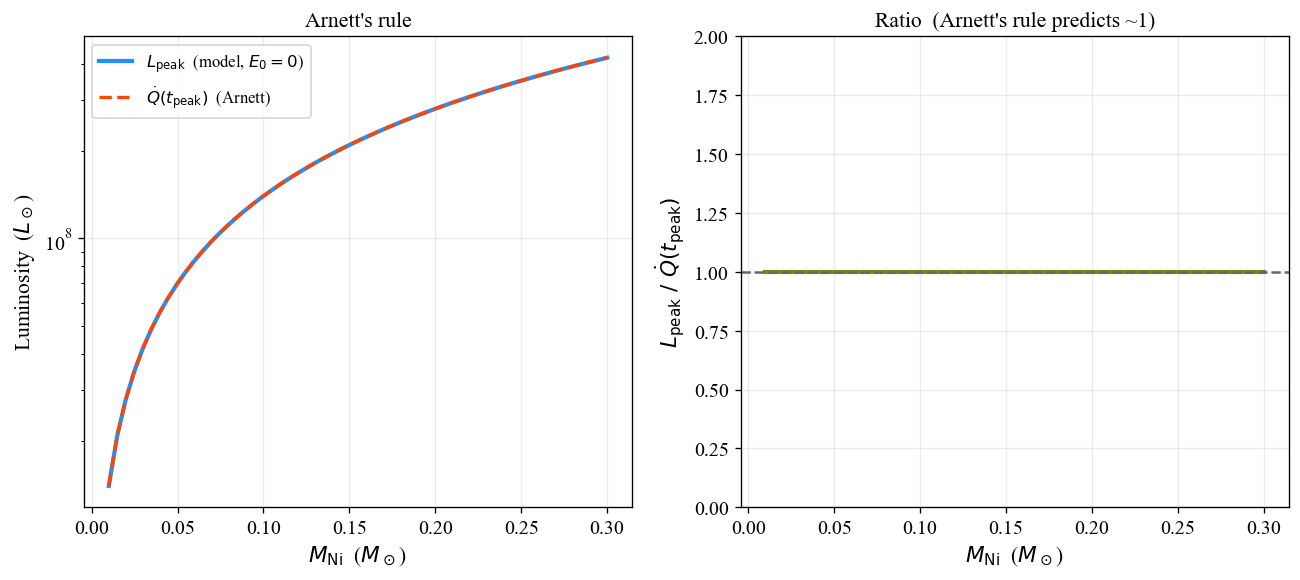

Mean ratio L_peak / Q(t_peak) = 0.9998   (Arnett predicts 1.0)


In [10]:
Ni_grid   = np.linspace(0.01, 0.30, 60)   # Msun
L_peaks   = []
Q_at_peak = []
t_peaks   = []

for Mni_sun in Ni_grid:
    Mni_g = Mni_sun * M_sun

    # E_0 = 0: pure radioactive driving, so Arnett's rule holds cleanly
    L_, tp_days, tm_days = run_model(M_ej, v_ej, kappa, Mni_g, 0.0, R_0, t_arr)

    # Use the NUMERICALLY FOUND peak time (not the analytic t_m - t0 estimate),
    # because tau_Co = 111 d is comparable to t_m and shifts the true peak later
    tp_actual_s = t_arr[np.argmax(L_)]

    L_peaks.append(np.max(L_))
    t_peaks.append(tp_actual_s / day)
    Q_at_peak.append(Q_dot(tp_actual_s, Mni=Mni_g))

L_peaks   = np.array(L_peaks)
Q_at_peak = np.array(Q_at_peak)
t_peaks   = np.array(t_peaks)
ratio     = L_peaks / Q_at_peak

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].plot(Ni_grid, L_peaks   / L_sun, color=COL_L,   lw=2.5, label=r'$L_{\rm peak}$  (model, $E_0=0$)')
axes[0].plot(Ni_grid, Q_at_peak / L_sun, color=COL_ODE, lw=2.0, ls='--', label=r"$\dot{Q}(t_{\rm peak})$  (Arnett)")
axes[0].set_xlabel(r'$M_{\rm Ni}$  ($M_\odot$)')
axes[0].set_ylabel(r'Luminosity  ($L_\odot$)')
axes[0].set_title("Arnett's rule")
axes[0].set_yscale('log')
axes[0].legend()

axes[1].plot(Ni_grid, ratio, color=COL_Q, lw=2.5)
axes[1].axhline(1.0, color='0.4', ls='--', lw=1.5)
axes[1].set_ylim(0, 2.0)
axes[1].set_xlabel(r'$M_{\rm Ni}$  ($M_\odot$)')
axes[1].set_ylabel(r'$L_{\rm peak}\ /\ \dot{Q}(t_{\rm peak})$')
axes[1].set_title("Ratio  (Arnett's rule predicts ~1)")

plt.tight_layout()
#plt.savefig('sn_arnett_rule.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean ratio L_peak / Q(t_peak) = {np.mean(ratio):.4f}   (Arnett predicts 1.0)")
